# Import

In [ ]:
# Repo-relative paths: inputs are read from imports_stable/, outputs are written to analysis_outs/
import os
from pathlib import Path
_here = Path.cwd().resolve()
REPO_DIR = str(next(p for p in [_here, *_here.parents] if (p / "imports_stable").is_dir()))
IMPORTS_DIR = f"{REPO_DIR}/imports_stable"
OUTS_DIR = f"{REPO_DIR}/analysis_outs/02_combinatorial_screen_signalseq_SIG13"
for _d in ["plots/qc_barcode_cutoff"]:
    os.makedirs(f"{OUTS_DIR}/{_d}", exist_ok=True)

In [1]:
import h5py
from anndata.io import read_elem
import rapids_singlecell as rsc
import scanpy as sc
import matplotlib as mpl
import matplotlib.pyplot as plt

plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 300
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype']  = 42
mpl.rcParams['text.usetex']  = False

PLOT_DIR = OUTS_DIR + "/plots/qc_barcode_cutoff"

In [2]:
# barcode modality for all cells
f = h5py.File(IMPORTS_DIR + "/SIG13/scanpy_outs/SIG13_full_bc_processed.h5mu", "r")
bc = read_elem(f["mod"]["bc"])

# match cells to DSB7 doublets
with h5py.File(IMPORTS_DIR + "/SIG13/scanpy_outs/SIG13_doublets_DSB7.h5ad", "r") as g:
    dsb7_obs = read_elem(g["obs"])

assert dsb7_obs.index.isin(bc.obs_names).all()
bc = bc[dsb7_obs.index].copy()
bc

AnnData object with n_obs × n_vars = 349678 × 74
    obs: 'lane'
    layers: 'counts', 'dsb'

# Clustering by BC expression

In [3]:
# add feature calls to bc
bc.obs['feature_call_DSB7'] = dsb7_obs['feature_call_DSB7']
bc.obs[['feature_call_round1_DSB7', 'feature_call_round2_DSB7']] = (
    bc.obs['feature_call_DSB7']
       .str.split('|', expand=True)
       .astype('category')
)

In [4]:
bc.X = bc.layers['counts'].copy()
rsc.get.anndata_to_GPU(bc)

In [5]:
rsc.pp.normalize_total(bc)
rsc.pp.log1p(bc)
rsc.pp.scale(bc)

In [6]:
rsc.pp.neighbors(bc, use_rep="X", metric='correlation')
rsc.tl.umap(bc, min_dist=0.3)

2026-09-22 21:03:18 | [INFO] maxp pruned
2026-09-22 21:03:18 | [INFO] cmap pruned
2026-09-22 21:03:18 | [INFO] kern dropped
2026-09-22 21:03:18 | [INFO] post pruned
2026-09-22 21:03:18 | [INFO] FFTM dropped
2026-09-22 21:03:18 | [INFO] GPOS pruned
2026-09-22 21:03:18 | [INFO] GSUB pruned
2026-09-22 21:03:18 | [INFO] glyf pruned
2026-09-22 21:03:18 | [INFO] Added gid0 to subset
2026-09-22 21:03:18 | [INFO] Added first four glyphs to subset
2026-09-22 21:03:18 | [INFO] Closing glyph list over 'MATH': 37 glyphs before
2026-09-22 21:03:18 | [INFO] Glyph names: ['.notdef', '.null', 'A', 'B', 'D', 'F', 'G', 'I', 'L', 'M', 'N', 'P', 'S', 'T', 'U', 'a', 'c', 'd', 'e', 'f', 'four', 'i', 'k', 'l', 'n', 'nonmarkingreturn', 'o', 'one', 'r', 'seven', 'six', 'space', 't', 'three', 'two', 'u', 'underscore']
2026-09-22 21:03:18 | [INFO] Glyph IDs:   [0, 1, 2, 3, 20, 21, 22, 23, 25, 26, 36, 37, 39, 41, 42, 44, 47, 48, 49, 51, 54, 55, 56, 66, 68, 70, 71, 72, 73, 76, 78, 79, 81, 82, 85, 87, 88]
2026-09-2

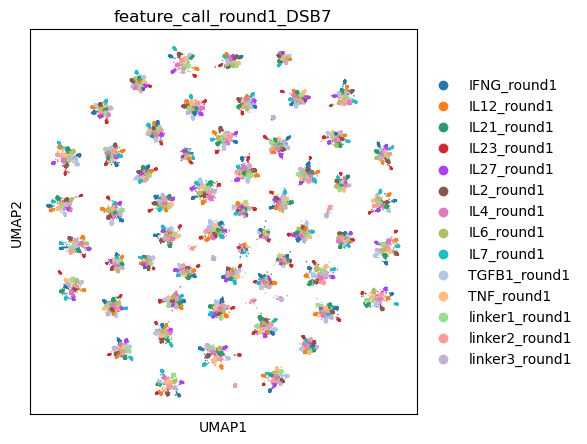

In [7]:
plt.rcParams['figure.figsize'] = (5,5)
g = sc.pl.umap(bc, color=['feature_call_round1_DSB7'], size=5, return_fig=True)
g.savefig(f"{PLOT_DIR}/barcode_calling_DSB7_ligand1.pdf")
g.savefig(f"{PLOT_DIR}/barcode_calling_DSB7_ligand1.png")

2026-09-22 21:03:40 | [INFO] maxp pruned
2026-09-22 21:03:40 | [INFO] cmap pruned
2026-09-22 21:03:40 | [INFO] kern dropped
2026-09-22 21:03:40 | [INFO] post pruned
2026-09-22 21:03:40 | [INFO] FFTM dropped
2026-09-22 21:03:40 | [INFO] GPOS pruned
2026-09-22 21:03:40 | [INFO] GSUB pruned
2026-09-22 21:03:40 | [INFO] glyf pruned
2026-09-22 21:03:40 | [INFO] Added gid0 to subset
2026-09-22 21:03:40 | [INFO] Added first four glyphs to subset
2026-09-22 21:03:40 | [INFO] Closing glyph list over 'MATH': 47 glyphs before
2026-09-22 21:03:40 | [INFO] Glyph names: ['.notdef', '.null', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'I', 'K', 'L', 'M', 'N', 'O', 'P', 'S', 'T', 'U', 'W', 'X', 'a', 'c', 'd', 'e', 'eight', 'f', 'five', 'four', 'i', 'k', 'l', 'n', 'nine', 'nonmarkingreturn', 'o', 'one', 'r', 'seven', 'six', 'space', 't', 'three', 'two', 'u', 'underscore', 'zero']
2026-09-22 21:03:40 | [INFO] Glyph IDs:   [0, 1, 2, 3, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 36, 37, 38, 39, 40, 41, 42, 44, 46, 47

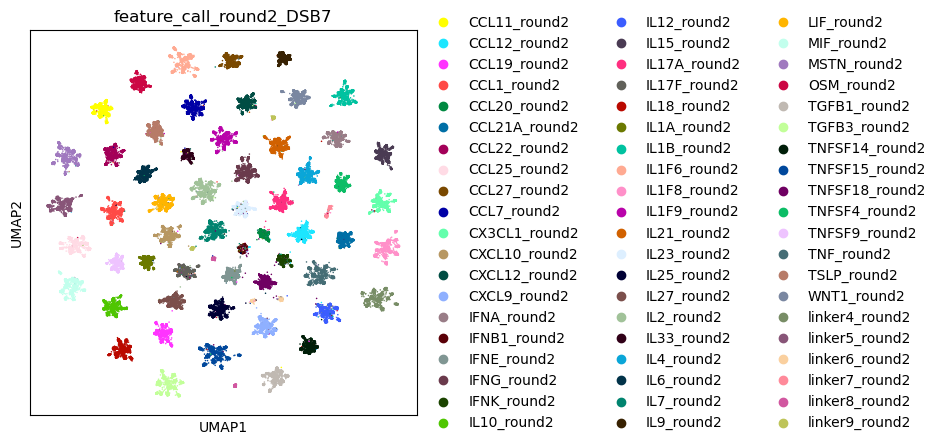

In [8]:
plt.rcParams['figure.figsize'] = (5,5)
g = sc.pl.umap(bc, color=['feature_call_round2_DSB7'], size=5, return_fig=True)
g.savefig(f"{PLOT_DIR}/barcode_calling_DSB7_ligand2.pdf")
g.savefig(f"{PLOT_DIR}/barcode_calling_DSB7_ligand2.png")